# T021 · 独热编码（One-Hot Encoding）

2020 年 CADD 研讨会开发，Volkamer 实验室，Charité/FU Berlin 

**注意：** 本教程是 TeachOpenCADD 的一部分，该平台旨在教授特定领域的技能，并为研究项目提供流程模板作为起点。

作者：

- Sakshi Misra, CADD 研讨会 2020, Charité/FU Berlin
- Talia B. Kimber, 2020, [Volkamer lab](https://volkamerlab.org), Charité
- Yonghui Chen, 2020, [Volkamer lab](https://volkamerlab.org), Charité
- Andrea Volkamer, 2020, [Volkamer lab](https://volkamerlab.org), Charité

## 本教程目标

本教程的目标是对 ChEMBL 数据集中一部分 SMILES 结构进行独热编码，以加深对独热编码概念的理解，以及为什么它在各种机器学习算法中作为预处理步骤非常有用。

### *理论* 部分内容

- 分子数据与表示
    - ChEMBL 数据库
    - SMILES 结构与规则
- 什么是分类数据？
     - 分类数据有什么问题？
     - 如何将分类数据转换为数值数据？
- 独热编码（One-Hot Encoding, OHE）概念
     - 为什么使用独热编码？
     - 独热编码示例
     - 独热编码的优点和缺点
- 类似方法：整数编码或标签编码
- 什么是 *填充（padding）*？
- 扩展阅读

### *实践* 部分内容

- 导入必要的包
- 读取输入数据
- 数据处理
     - 双字符替换
     - 计算最长（和最短）SMILES
- Python 独热编码实现
     - 独热编码（padding=True）
     - 可视化
          - 最短 SMILES
          - 最长 SMILES 
- 补充材料
   - Scikit-learn 实现
   - Keras 实现

## 参考文献

- 理论背景：
     - ChEMBL 数据库: "The ChEMBL bioactivity database: an update." ([<i>Nucleic acids research<i> (2014), <b>42.D1</b>, D1083-D1090](https://doi.org/10.1093/nar/gkt1031))
     - Allen Chieng Hoon Choong, Nung Kion Lee, "*Evaluation of Convolutionary Neural Networks Modeling of DNA Sequences using Ordinal versus one-hot Encoding Method*", [bioRxiv, October 25, 2017](https://doi.org/10.1101/186965).
     - Patricio Cerda, Gael Varoquaux, "*Encoding high-cardinality string categorical variables*", [arXiv:1907, 18 May 2020](https://arxiv.org/pdf/1907.01860v5.pdf).
     - 博客文章: Jason Brownlee, *How to One Hot Encode Sequence Data in Python*, [Machine Learning Mastery, accessed November 9th, 2020](https://machinelearningmastery.com/how-to-one-hot-encode-sequence-data-in-python/).
     - 博客文章: Krishna Kumar Mahto, *One-Hot-Encoding, Multicollinearity and the Dummy Variable Trap*, medium, Available at [one-hot-encoding-multicollinearity](https://medium.com/data-science/one-hot-encoding-multicollinearity-and-the-dummy-variable-trap-b5840be3c41a), accessed March 25th, 2026.
     - 博客文章: Chris, *What is padding in a neural network?*, archieved from MachineCurve, [Padding](https://github.com/christianversloot/machine-learning-articles/blob/main/what-is-padding-in-a-neural-network.md)
     

- 包和函数：
     - [**RDKit**](https://www.rdkit.org/docs/GettingStartedInPython.html): Greg Landrum,  *RDKit Documentation*, [PDF](https://buildmedia.readthedocs.org/media/pdf/rdkit/latest/rdkit.pdf), Release on 2019.09.1.
     - [**Scikit-learn**](https://scikit-learn.org/stable/): 
        - [Scikit-learn: Machine Learning in Python](https://jmlr.csail.mit.edu/papers/v12/pedregosa11a.html), Pedregosa *et al.*, JMLR 12, pp. 2825-2830, 2011.
        - Jiangang Hao, et al. "A Review of Scikit-learn Package in Python Programming Language." [*Journal of Education and Behavioral Statistics* **Volume: 44 issue: 3** (2019), page(s): 348-361](https://doi.org/10.3102/1076998619832248)
     - [**Keras**](https://keras.io/): Book chapter: "An Introduction to Deep Learning and Keras" in [*Learn Keras for Deep Neural Networks* (2019), **page(s):1-16**](https://doi.org/10.1007/978-1-4842-4240-7).
     - [**Matplotlib**](https://matplotlib.org/)
     - `smiles encoder` 函数: Blogpost by iwatobipen, *encode and decode SMILES strings* , [Wordpress, accessed November 9th, 2020](https://iwatobipen.wordpress.com/2017/01/22/encode-and-decode-smiles-strings/)

In [68]:
import sys

if "google.colab" in sys.modules:
    %pip install teachopencadd --no-deps -q
    !teachopencadd -d 21
    %pip uninstall teachopencadd -y -q
    %pip install -qr requirements.txt

## Theory

### 分子数据与表示

#### ChEMBL 数据库

- [ChEMBL](https://www.ebi.ac.uk/chembl/) 是一个开放的大规模生物活性数据库，包含具有类药物性质的分子。 
- 最新版本（版本 25）包含从超过 $72,000$ 篇文档中提取的信息。目前总共有超过 $1.8$ 百万个化合物和 $15$ 百万个生物活性数据点可用。
- 它由[欧洲生物信息学研究所](https://en.wikipedia.org/wiki/European_Bioinformatics_Institute)维护。更多详情请参见 **教程 T001**。

#### SMILES 结构与规则

- [SMILES](https://en.wikipedia.org/wiki/Simplified_molecular-input_line-entry_system)（简化分子线性输入规范）是一种化学表示法，允许用户以线性的方式表示分子的化学结构，使计算机可读（参见 "Modern Aspects of the Smiles Rearrangement" (2017), [*Chemistry A European Journal*, **Volume23, Issue38**, 8992-9008](https://doi.org/10.1002/chem.201700353) 了解更多信息）。
- 它包含一系列字母、数字和字符，用于指定分子的原子、连接方式、键级和手性。

**SMILES 规范的一些规则**

- **原子** - 用其原子符号表示。金属原子也用方括号中的符号表示，例如金 `[Au]`。
- **化学键** - 单键、双键和三键分别用符号 `-`、`=` 和 `#` 表示。单键是默认值，因此无需指定。 
- **芳香性** - 原子符号通常使用大写，如 `C`、`O`、`S` 和 `N`；而指定芳香原子时则使用小写符号，如 `c`、`o`、`s` 和 `n`。有时也使用环中的隐式键（交替的 `=` 和 `-`）来描述芳香原子，例如 `C1=CC=CC=C1`。
- **环** - SMILES 允许用户通过使用数字标识开环和闭环原子来识别环结构。例如，在 `C1CCCCC1` 中，第一个碳原子标有数字 "1"，它通过单键与同样标有数字 "1" 的最后一个碳原子连接。得到的结构是环己烷。
- **支链** - 通过将支链括在括号中来指定，可以嵌套或排列。例如，2-丙醇用 `CC(O)C` 表示。

### 什么是分类数据？

分类数据是包含标签而非数值的变量。
以下是一些示例：

- 一个 "宠物" 变量，取值为："狗" 和 "猫"。
- 一个 "颜色" 变量，取值为："红色"、"绿色" 和 "蓝色"。
- 一个 "名次" 变量，取值为："第一"、"第二" 和 "第三"。

#### 分类数据有什么问题？

机器学习由通过低级编程语言转换为计算机指令的数学运算组成。计算机在处理数字方面非常出色，因此我们必须以某种方式将输入数据转换为数字。
许多机器学习算法无法直接处理分类数据。因此，分类数据必须转换为数值形式，使所有输入和输出变量都是数值（参见[**博客文章**](https://www.analyticsvidhya.com/blog/2020/03/one-hot-encoding-vs-label-encoding-using-scikit-learn/): Alakh Sethi, *One-Hot Encoding vs. Label Encoding using Scikit-Learn* , Analytics Vidya, accessed March 6th, 2020 了解更多信息）。

![计算机数据](./images/computer_data.jpeg)

*图 1*: 显示计算机理解输入所需的分类编码。该图来自这篇[博客文章](https://www.analyticsvidhya.com/blog/2020/03/one-hot-encoding-vs-label-encoding-using-scikit-learn/)。

#### 如何将分类数据转换为数值数据？

有许多方法可以将分类值转换为数值。每种方法对特征集都有其自身的正面和负面影响。这里，我们将重点讨论两种主要方法：*独热*编码和*标签*编码。
这两种编码器都是 [scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html) 库（最广泛使用的 Python 库之一）的一部分，用于将文本或分类数据转换为模型所需并能处理的数值数据。

### *独热编码*（One-Hot Encoding, OHE）概念

独热编码是一种向量表示，其中向量的所有元素都设置为 `0`，除了一个元素具有 `1` 作为其值。例如，`[0 0 0 1 0 0]` 就是一个独热向量。
简而言之，独热编码（也称为二进制编码）是将分类变量表示为二进制向量的二进制表示法。

下图帮助我们从整体上理解独热编码的概念。

![独热编码](./images/OneHotEncoding.png)

*图 2* : 展示甲苯分子的独热编码。图片取自文章 [<i>BMC Bioinformatics.</i> (2018), <b>19</b>,526](https://doi.org/10.1186/s12859-018-2523-5)，可在该文章中找到更多信息。

让我们通过一个简单的示例更深入地了解独热编码这一概念，该示例将描述独热编码的基本概念、它的用处以及如何实现。

#### 为什么使用独热编码？

独热编码使分类数据的表示更具表达性。
许多机器学习算法难以直接处理分类数据，这就是为什么分类标签值必须首先转换为数字作为预处理步骤。无论是输入变量还是输出变量，只要它们是分类数据，都需要进行这一转换。

我们也可以直接使用*整数编码*。这对于类别之间存在自然顺序关系（进而整数值之间存在关系）的问题可能有效，例如温度标签 "冷"、"暖" 和 "热"。
当没有顺序关系时，使用整数编码来依赖任何此类关系来解决问题可能没有帮助。一个例子是标签 "狗" 和 "猫"。

#### 独热编码示例

让我们看一个非常简单的例子来理解这个概念。假设我们有一个 "颜色" 变量，它有三个标签 `红色`、`蓝色` 和 `绿色`。
所有这些标签必须转换为数值形式，以便我们的机器学习算法能够处理。这可以通过创建三个新列来实现，每列对应一个标签，对于相应标签的颜色使用 `1`，对于其他颜色使用 `0`，如图 3 所示。

![独热编码](images/OneHotEncoding_eg.png)

*图 3* : 对变量 "颜色" 进行独热编码的可视化演示。图片取自文章: "*Building a One Hot Encoding Layer with TensorFlow*", George Novack, [medium](https://medium.com/data-science/building-a-one-hot-encoding-layer-with-tensorflow-f907d686bf39)，可在该文章中找到更多详细信息。

#### 独热编码的优点和缺点

**优点**
- 如果分类特征的基数（类别数量）较低（相对于数据量），独热编码效果最好。
- 独热编码的优点是结果是二元的而非有序的，并且所有内容都位于正交向量空间中。

**缺点**
- 维度增加：在基于分类变量添加多个列之后，可能导致计算成本增加。
- 由于哑变量（添加为特征的唯一类别）可能导致多重共线性，进而影响模型的性能。
- 独热编码可能导致数据集的[稀疏性](https://en.wikipedia.org/wiki/Sparse_matrix)增加（稀疏矩阵是一种大多数元素为零的矩阵）。

### 类似方法：整数编码或标签编码

[标签编码](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html)（即整数编码）是一种处理分类变量的流行编码技术，且易于反向转换。在这种技术中，每个标签根据字母顺序被分配一个唯一的整数，以便机器能够正确处理它。
然后，机器学习算法可以更好地决定标签应该如何被操作。
对于监督学习中的结构化数据集，这是一个重要的预处理步骤。

**整数编码示例**

让我们使用一个与上面类似的例子：我们有一个颜色变量，可以将 `红色` 赋值为 `0`，`绿色` 赋值为 `1`，`蓝色` 赋值为 `2`，如图 4 所示。

![标签编码示例](./images/label_encoding_example.png)

*图 4* : 对变量 "颜色" 进行标签编码的可视化演示。图片取自文章: "*Know about Categorical Encoding, even New Ones!*", Ahmed Othmen, towardsdatascience（现已下线），可在该文章中找到更多详细信息。

**标签编码与独热编码的区别**

这两种编码技术之间没有太大区别，主要取决于所使用的数据类型和模型。例如，如果我们有不具有顺序关系的分类特征（狗或猫），则可以使用独热编码。标签编码最适合顺序数据，如 `差=0, 较好=1, 最好=2`。
此外，当分类变量很多时，选择标签编码可能是好的选择，以避免高内存消耗和稀疏性。

### 什么是 *填充（padding）*？

填充用于在生成的独热编码矩阵中添加零。有不同类型的填充，我们在此选择了零填充。更多详情请参见此[文章](https://github.com/christianversloot/machine-learning-articles/blob/main/what-is-padding-in-a-neural-network.md)。

**为什么要进行填充？**

填充的目的是使矩阵的维度相等——或保持高度和宽度——并在用作深度学习模型输入时无需过多担心张量维度。


**如何进行填充？**

填充可以使用 [numpy.pad](https://numpy.org/doc/stable/reference/generated/numpy.pad.html) 函数来执行，该函数接受多个参数，如需要填充的 `array`、添加到每个轴边缘的值的数量 `pad_width`，以及默认为 "constant" 的 `mode`。

在本教程中，*填充* 以以下方式进行：

- *隐式*：在对预处理数据应用 Python 实现进行独热编码时，我们传入字符串的最大长度作为参数，使所有生成的独热编码矩阵具有相同的维度。
- *显式*：更多信息可以在**补充部分**中找到，我们在那里使用 *keras* 和 *scikit-learn* 实现来应用独热编码。

### 扩展阅读

本节列出了一些进一步阅读的资源：

- [What is one-hot encoding and when is it used in data science?](https://www.quora.com/What-is-one-hot-encoding-and-when-is-it-used-in-data-science)
- [Categorical encoding using Label-Encoding and One-Hot-Encoder](https://towardsdatascience.com/categorical-encoding-using-label-encoding-and-one-hot-encoder-911ef77fb5bd#:~:text=One%2DHot%20Encoding%20in%20Python&text=OneHotEncoder%20from%20SciKit%20library%20only,apply%20OneHotEncoder%20on%20column%20Bridge_Types_Cat.)
- Hirohara, M., Saito, Y., Koda, Y. et al. Convolutional neural network based on SMILES representation of compounds for detecting chemical motif. [_BMC Bioinformatics_ **19**, 526 (2018)](https://doi.org/10.1186/s12859-018-2523-5)
- [How one can use matplotlib.pyplot.imshow() in Python](https://www.geeksforgeeks.org/matplotlib-pyplot-imshow-in-python/)

## 实践

### 导入必要的包

In [69]:
import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

from pathlib import Path
from warnings import filterwarnings

import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Draw, PandasTools
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.text import Tokenizer
import matplotlib.pyplot as plt

# 静默一些预期的警告
filterwarnings("ignore")

In [70]:
# 设置此 notebook 的路径
HERE = Path(_dh[-1])
DATA = HERE / "data"

### 读取输入数据

使用 Pandas 库，我们首先加载 ChEMBL 数据集的子集，并使用 `rdkit.draw` 函数绘制分子。然后我们对数据进行预处理并应用我们的 `独热编码` Python 实现。

让我们加载数据并快速分析其列值，检查是否存在缺失值:

In [71]:
df = pd.read_csv(DATA / "CHEMBL25_activities_EGFR.csv", index_col=0).reset_index(drop=True)
print(f"Shape of dataframe: {df.shape}\n")
# NBVAL_CHECK_OUTPUT

Shape of dataframe: (3905, 5)



检查数据的维度和缺失值

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3905 entries, 0 to 3904
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   chembl_id         3905 non-null   object 
 1   IC50              3905 non-null   float64
 2   units             3905 non-null   object 
 3   canonical_smiles  3905 non-null   object 
 4   pIC50             3905 non-null   float64
dtypes: float64(2), object(3)
memory usage: 152.7+ KB


查看前 3 行

In [73]:
df.head(3)
# NBVAL_CHECK_OUTPUT

,chembl_id,IC50,units,canonical_smiles,pIC50
0,CHEMBL207869,77.0,nM,Clc1c(OCc2cc(F)ccc2)ccc(Nc2c(C#Cc3ncccn3)cncn2)c1,7.113509
1,CHEMBL3940060,330.0,nM,ClCC(=O)OCCN1C(=O)Oc2c1cc1c(Nc3cc(Cl)c(F)cc3)n...,6.481486
2,CHEMBL3678951,1.0,nM,FC(F)(F)c1cc(Nc2n(C(C)C)c3nc(Nc4ccc(N5CC[NH+](...,9.000000


选择我们研究所需的列

In [74]:
df = df[["chembl_id", "canonical_smiles"]]

我们可以使用 pandas 工具和 `draw` 方法可视化分子及其 ChEMBL ID，如下所示。

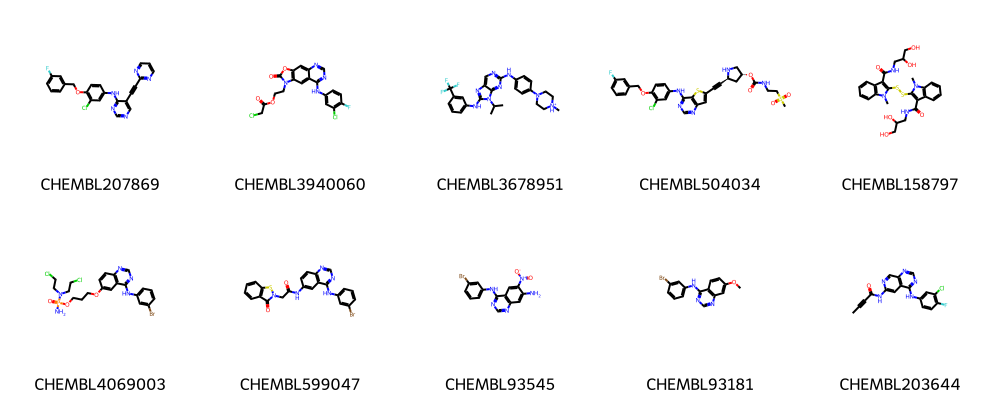

In [75]:
# 使用 PandasTools 和相应的 Draw 方法
PandasTools.AddMoleculeColumnToFrame(df, smilesCol="canonical_smiles", molCol="Mol2D")
Draw.MolsToGridImage(list(df.Mol2D[0:10]), legends=list(df.chembl_id[0:20]), molsPerRow=5)

### 数据处理

SMILES 预处理：由于在 SMILES 表示中，原子可以用一个或两个字符来描述（取决于它们代表的周期表元素），而机器会按位置读取输入，因此我们将 SMILES 转换为化学感知的表示形式。

- 首先，我们搜索当前数据集中存在的所有唯一字符，这使我们能够删除当前数据中不存在的字符。

- 其次，我们通过将字符串中存在的原子与周期表中所有可能的元素进行比较，搜索 SMILES 数据集中的所有双字符元素，并将所有双字母元素替换为*人工*选择的单字符，例如将 `Cl` 替换为 `L`。

关于填充:

- SMILES 字符串由于长度不同而具有不同的维度。对于机器学习应用，数据集中的维度必须相等。为此，我们可以首先查找具有最大长度的 SMILES 字符串（例如 [len()](https://www.geeksforgeeks.org/python-string-length-len/) 方法），并在函数中将其作为参数传递给所有字符串。

#### 双字符替换

In [76]:
def assess_two_letter_elements(df):
    """
    在数据框中查找双字母元素。

    参数
    ----------
    df : pandas.DataFrame
        需要预处理的数据框。

    返回
    -------
    two_letter_elements : list
        找到的双字母元素列表。
    """

    # 在 SMILES 字符串中搜索唯一字符
    unique_chars = set(df.canonical_smiles.apply(list).sum())
    # 仅获取大写和小写字母
    upper_chars = []
    lower_chars = []
    for entry in unique_chars:
        if entry.isalpha():
            if entry.isupper():
                upper_chars.append(entry)
            elif entry.islower():
                lower_chars.append(entry)
    print(f"Upper letter characters {sorted(upper_chars)}")
    print(f"Lower letter characters {sorted(lower_chars)}")

    # 周期表中所有可能的元素列表
    periodic_elements = [
        "Ac",
        "Al",
        "Am",
        "Sb",
        "Ar",
        "As",
        "At",
        "Ba",
        "Bk",
        "Be",
        "Bi",
        "Bh",
        "B",
        "Br",
        "Cd",
        "Ca",
        "Cf",
        "C",
        "Ce",
        "Cs",
        "Cl",
        "Cr",
        "Co",
        "Cn",
        "Cu",
        "Cm",
        "Ds",
        "Db",
        "Dy",
        "Es",
        "Er",
        "Eu",
        "Fm",
        "Fl",
        "F",
        "Fr",
        "Gd",
        "Ga",
        "Ge",
        "Au",
        "Hf",
        "Hs",
        "He",
        "Ho",
        "H",
        "In",
        "I",
        "Ir",
        "Fe",
        "Kr",
        "La",
        "Lr",
        "Pb",
        "Li",
        "Lv",
        "Lu",
        "Mg",
        "Mn",
        "Mt",
        "Md",
        "Hg",
        "Mo",
        "Mc",
        "Nd",
        "Ne",
        "Np",
        "Ni",
        "Nh",
        "Nb",
        "N",
        "No",
        "Og",
        "Os",
        "O",
        "Pd",
        "P",
        "Pt",
        "Pu",
        "Po",
        "K",
        "Pr",
        "Pm",
        "Pa",
        "Ra",
        "Rn",
        "Re",
        "Rh",
        "Rg",
        "Rb",
        "Ru",
        "Rf",
        "Sm",
        "Sc",
        "Sg",
        "Se",
        "Si",
        "Ag",
        "Na",
        "Sr",
        "S",
        "Ta",
        "Tc",
        "Te",
        "Ts",
        "Tb",
        "Tl",
        "Th",
        "Tm",
        "Sn",
        "Ti",
        "W",
        "U",
        "V",
        "Xe",
        "Yb",
        "Y",
        "Zn",
        "Zr",
    ]

    # two_char_elements 列表包含所有双字母元素
    # 可以通过大写 x 小写字符的所有可能组合生成
    # 并且是有效的周期表元素。
    two_char_elements = []
    for upper in upper_chars:
        for lower in lower_chars:
            ch = upper + lower
            if ch in periodic_elements:
                two_char_elements.append(ch)

    # 然后将此列表缩减为实际出现在 SMILES 字符串中的
    # 双字母元素子集，特定于我们的数据集。
    two_char_elements_smiles = set()
    for char in two_char_elements:
        if df.canonical_smiles.str.contains(char).any():
            two_char_elements_smiles.add(char)

    return two_char_elements_smiles

In [77]:
elements_found = assess_two_letter_elements(df)
print(f"\nTwo letter elements found in the data set: {sorted(elements_found)}")
# NBVAL_CHECK_OUTPUT

Upper letter characters ['B', 'C', 'F', 'H', 'I', 'N', 'O', 'P', 'S']
Lower letter characters ['c', 'e', 'l', 'n', 'o', 'r', 's']

Two letter elements found in the data set: ['Br', 'Cl', 'Cn', 'Sc', 'Se']


基于这一发现，我们定义了自己的替换字典。请注意，这个 *简单* 实现存在一些不足之处，我们在此（部分）手动处理：

- 我们将 `Sc` 和 `Cn` 排除在替换之外，因为分子中含有硫 `S` 和芳香碳 `c` 的可能性比钪 `Sc` 更大，同样碳 `C` 和芳香氮 `n` 比鎶 `Cn` 更常见。因此，仅替换氯 `Cl`、溴 `Br` 和硒 `Se`。
- 在异构 SMILES 中，`@` 和 `@@` 用于描述对映异构体，因此我们也需要将后者替换为单字符代码。
- 如果你使用不同的数据集，可能需要调整下面的映射字典。

这产生了以下字典，用于替换在此数据集中找到的双字符元素

In [78]:
replace_dict = {"Cl": "L", "Br": "R", "Se": "X", "@@": "Z"}

基于此字典，我们定义一个函数来创建预处理后的数据。

In [79]:
def preprocessing_data(df, replacement):
    """
    预处理数据集中的 SMILES 结构。

    参数
    ----------
    df : pandas.DataFrame
      需要预处理的数据框。
    replacement : dict
      用于替换的映射字典。

    返回
    -------
    df : pandas.DataFrame
        带有新处理后的规范 SMILES 列的数据框。
    unique_char : list
        SMILES 中存在的唯一字符列表。
    """
    # 如果数据集中有 'Sc' 元素，打印警告
    if df.canonical_smiles.str.contains("Sc").any():
        print(
            '警告: 数据集中发现 "Sc" 元素，由于该元素在药物中很少出现， '
            "因此我们不将其转换为单字母元素,"
            '而是将 "S" '
            '和 "c" 视为单独的元素。 '
        )

    # 创建一个包含处理后的规范 SMILES 的新列
    df["processed_canonical_smiles"] = df["canonical_smiles"].copy()

    # 将找到的双字母元素替换为单字符
    for pattern, repl in replacement.items():
        df["processed_canonical_smiles"] = df["processed_canonical_smiles"].str.replace(
            pattern, repl
        )

    unique_char = set(df.processed_canonical_smiles.apply(list).sum())
    return df, unique_char

In [80]:
# 调用函数
df, unique_char = preprocessing_data(df, replace_dict)
df.head(3)

,chembl_id,canonical_smiles,Mol2D,processed_canonical_smiles
0,CHEMBL207869,Clc1c(OCc2cc(F)ccc2)ccc(Nc2c(C#Cc3ncccn3)cncn2)c1,<rdkit.Chem.rdchem.Mol object at 0x13d0fe3b0>,Lc1c(OCc2cc(F)ccc2)ccc(Nc2c(C#Cc3ncccn3)cncn2)c1
1,CHEMBL3940060,ClCC(=O)OCCN1C(=O)Oc2c1cc1c(Nc3cc(Cl)c(F)cc3)n...,<rdkit.Chem.rdchem.Mol object at 0x13d0fdd20>,LCC(=O)OCCN1C(=O)Oc2c1cc1c(Nc3cc(L)c(F)cc3)ncn...
2,CHEMBL3678951,FC(F)(F)c1cc(Nc2n(C(C)C)c3nc(Nc4ccc(N5CC[NH+](...,<rdkit.Chem.rdchem.Mol object at 0x13d0fe490>,FC(F)(F)c1cc(Nc2n(C(C)C)c3nc(Nc4ccc(N5CC[NH+](...


In [81]:
# 打印唯一字符
print(f"All unique characters found in the preprocessed data set:\n{sorted(unique_char)}")
# NBVAL_CHECK_OUTPUT

All unique characters found in the preprocessed data set:
['#', '(', ')', '+', '-', '/', '0', '1', '2', '3', '4', '5', '6', '7', '=', '@', 'B', 'C', 'F', 'H', 'I', 'L', 'N', 'O', 'P', 'R', 'S', 'X', 'Z', '[', '\\', ']', 'c', 'n', 'o', 's']


#### 计算最长（和最短）SMILES

这里，我们计算数据框中最长和最短 SMILES 的长度和索引，稍后我们将在可视化部分中使用它们。

In [82]:
# 最长 SMILES 字符串的索引
longest_smiles = max(df["canonical_smiles"], key=len)
longest_smiles_index = df.canonical_smiles[df.canonical_smiles == longest_smiles].index.tolist()
print(f"Longest SMILES: {longest_smiles}")
print(f"Contains {len(longest_smiles)} characters, index in dataframe: {longest_smiles_index[0]}.")
smiles_maxlen = len(longest_smiles)
# NBVAL_CHECK_OUTPUT

Longest SMILES: O=C(N[C@@H]1C(=O)N[C@H](CCC[NH3+])C(=O)N[C@@H]([C@H](CC)C)C(=O)N[C@H](Cc2ccccc2)C(=O)N[C@@H](Cc2[nH]cnc2)C(=O)N[C@H](CC(=O)[O-])C(=O)N[C@@H](CC(=O)N)C(=O)NCCCC1)[C@@H](NC(=O)[C@H](NC(=O)[C@@H](NC(=O)[C@H]1N=C([C@@H]([NH3+])[C@H](CC)C)SC1)CC(C)C)CCC(=O)[O-])[C@H](CC)C
Contains 267 characters, index in dataframe: 2704.


In [83]:
# 最短 SMILES 字符串的索引
shortest_smiles = min(df["canonical_smiles"], key=len)
shortest_smiles_index = df.canonical_smiles[df.canonical_smiles == shortest_smiles].index.tolist()
print(f"Shortest SMILES: {shortest_smiles}")
print(
    f"Contains {len(shortest_smiles)} characters, index in dataframe: {shortest_smiles_index[0]}."
)
# NBVAL_CHECK_OUTPUT

Shortest SMILES: Oc1c(O)cccc1
Contains 12 characters, index in dataframe: 3428.


### Python 独热编码实现

#### 独热编码（padding=True）

我们定义一个函数 `smiles_encoder`，它接收 SMILES、用于填充的 SMILES 字符串最大长度（`max_len`）以及 `processed_canonical_smiles` 列中存在的唯一字符列表（`unique_char`），并返回固定形状的独热编码矩阵。

In [84]:
# 定义用于创建独热编码矩阵的函数
def smiles_encoder(smiles, max_len, unique_char):
    """
    使用预处理数据集中所有唯一字符定义的函数，
    这些唯一字符来自通过 preprocessing_data 函数创建的
    预处理后的规范 SMILES 结构。

    参数
    ----------
    smiles : str
         字符串格式的分子的 SMILES。
    unique_char : list
         字符串数据集中唯一字符的列表。
    max_len : int
         SMILES 字符串的最大长度。

    返回
    -------
    smiles_matrix : numpy.ndarray
         固定形状的独热编码矩阵
         （SMILES 中唯一字符数, SMILES 最大长度）。
    """
    # 创建唯一字符数据集的字典
    smi2index = {char: index for index, char in enumerate(unique_char)}
    # 独热编码
    # 零填充至 max_len
    smiles_matrix = np.zeros((len(unique_char), max_len))
    for index, char in enumerate(smiles):
        smiles_matrix[smi2index[char], index] = 1
    return smiles_matrix

In [85]:
# 将函数应用于处理后的规范 SMILES 字符串
df["unique_char_ohe_matrix"] = df["processed_canonical_smiles"].apply(
    smiles_encoder, max_len=smiles_maxlen, unique_char=unique_char
)
df.head(3)

,chembl_id,canonical_smiles,Mol2D,processed_canonical_smiles,unique_char_ohe_matrix
0,CHEMBL207869,Clc1c(OCc2cc(F)ccc2)ccc(Nc2c(C#Cc3ncccn3)cncn2)c1,<rdkit.Chem.rdchem.Mol object at 0x13d0fe3b0>,Lc1c(OCc2cc(F)ccc2)ccc(Nc2c(C#Cc3ncccn3)cncn2)c1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
1,CHEMBL3940060,ClCC(=O)OCCN1C(=O)Oc2c1cc1c(Nc3cc(Cl)c(F)cc3)n...,<rdkit.Chem.rdchem.Mol object at 0x13d0fdd20>,LCC(=O)OCCN1C(=O)Oc2c1cc1c(Nc3cc(L)c(F)cc3)ncn...,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
2,CHEMBL3678951,FC(F)(F)c1cc(Nc2n(C(C)C)c3nc(Nc4ccc(N5CC[NH+](...,<rdkit.Chem.rdchem.Mol object at 0x13d0fe490>,FC(F)(F)c1cc(Nc2n(C(C)C)c3nc(Nc4ccc(N5CC[NH+](...,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."


#### 可视化

Matplotlib 是 Python 编程语言的绘图库，Pyplot 是 matplotlib 模块的基于状态的接口，提供类似 MATLAB 的接口。
matplotlib 库的 pyplot 模块中的 [imshow](https://matplotlib.org/3.2.1/api/_as_gen/matplotlib.pyplot.imshow.html) 函数用于将数据显示为图像，即在二维空间上显示。

我们通过定义 `one_hot_matrix_plot` 函数来使用 `imshow` 可视化我们的独热编码矩阵，如下所示。

In [86]:
def one_hot_matrix_plot(ohe_matrix, smiles_char, smiles):
    """
    使用 matplotlib imshow() 函数
    可视化独热编码矩阵。

    参数
    ----------
    ohe_matrix : numpy.ndarray
       形状为 (`smiles_char`, `len(smiles)`) 的
       独热编码（ohe）矩阵。
    smiles_char : list
        所有可能的 SMILES 字符列表。
    smiles : string
        相应分子的原始 SMILES 字符串。

    返回
    ------
    None

    """
    im = plt.imshow(ohe_matrix, cmap="hot", interpolation="None")
    plt.xlabel("Length of SMILES string")
    plt.ylabel(f"Char in SMILES ({len(smiles_char)})")
    plt.title("Visualization of one-hot encoded matrix")
    plt.show()
    print("Shape of one-hot matrix : ", ohe_matrix.shape)
    print("Associated canonical SMILES: ", smiles)
    return None

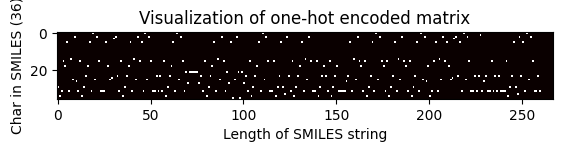

Shape of one-hot matrix :  (36, 267)
Associated canonical SMILES:  O=C(N[C@@H]1C(=O)N[C@H](CCC[NH3+])C(=O)N[C@@H]([C@H](CC)C)C(=O)N[C@H](Cc2ccccc2)C(=O)N[C@@H](Cc2[nH]cnc2)C(=O)N[C@H](CC(=O)[O-])C(=O)N[C@@H](CC(=O)N)C(=O)NCCCC1)[C@@H](NC(=O)[C@H](NC(=O)[C@@H](NC(=O)[C@H]1N=C([C@@H]([NH3+])[C@H](CC)C)SC1)CC(C)C)CCC(=O)[O-])[C@H](CC)C


In [87]:
# 传递最长 SMILES 字符串的索引以可视化矩阵
one_hot_matrix_plot(
    df.iloc[longest_smiles_index[0]]["unique_char_ohe_matrix"], unique_char, longest_smiles
)

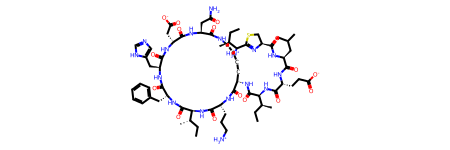

In [88]:
# 绘制最长 SMILES 的分子
longest_smiles_mol = Chem.MolFromSmiles(longest_smiles)
longest_smiles_mol

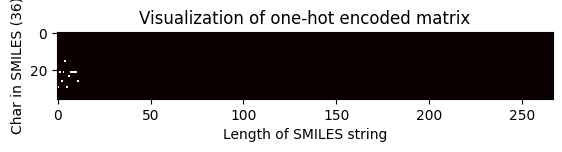

Shape of one-hot matrix :  (36, 267)
Associated canonical SMILES:  Oc1c(O)cccc1


In [89]:
# 传递最短 SMILES 字符串的索引以可视化矩阵
one_hot_matrix_plot(
    df.iloc[shortest_smiles_index[0]]["unique_char_ohe_matrix"], unique_char, shortest_smiles
)

通过上面的 matplotlib `imshow` 函数完成了矩阵可视化，我们也可以使用 `numpy.matrix` 函数可视化整个矩阵，例如最长 SMILES 字符串的独热编码矩阵如下所示。

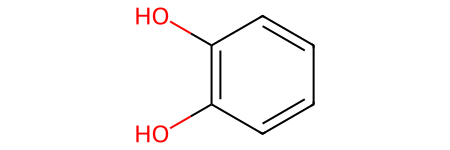

In [90]:
# 绘制最短 SMILES 的分子
shortest_smiles_mol = Chem.MolFromSmiles(shortest_smiles)
shortest_smiles_mol

In [91]:
# 打印最长 SMILES 分子矩阵的部分行
np.set_printoptions(threshold=np.inf)
subset = 3
unique_char = list(unique_char)
print(
    f"First {subset} rows of the ohe matrix, representing the characters {unique_char[0:subset]}\n"
)
print(np.matrix(df.iloc[longest_smiles_index[0]]["unique_char_ohe_matrix"])[0:subset, :])

First 3 rows of the ohe matrix, representing the characters ['@', 'S', ']']

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 

## 讨论

在计算机辅助药物发现和开发领域，机器学习技术已被用于开发新型候选药物。设计药物靶点和发现新药的方法现在通常结合机器学习和深度学习算法，以提高开发输出的效率、效果和质量。

但要使用任何机器学习或深度学习算法，输入数据必须是机器可读的格式。在计算机辅助药物设计中，我们主要处理分类或文本数据，即使用 SMILES 字符串格式表示的药物分子，因此我们必须将这些分类数据转换为数值格式。

**独热编码**是一种流行且高效的编码技术，可将数据转换为数值格式。它可以作为应用任何机器学习或深度学习算法之前的重要预处理步骤。

在本教程中，我们在预处理数据之后应用了独热编码，以克服一些不足之处，例如：

- 使独热编码矩阵具有相同的维度，因为 SMILES 字符串的长度可能不同，而大多数机器学习应用需要数据集中具有相等的维度。

- 将双字符元素（如 `Cl`）替换为单字符，因为在进行独热编码时，它会把 `Cl` 拆分为两个字符，即 `C` 和 `l`，这可能导致不一致。

- 查找数据集中唯一的字符，以生成更稀疏的独热编码矩阵。


独热编码在各个领域有多种应用，例如：

- __机器学习（神经网络）__: 在机器学习中，独热编码是处理分类数据的一种常用方法，因为许多机器学习模型需要其输入变量为数值。

- __自然语言处理（NLP）__: 在 NLP 中，大多数情况下数据由词汇语料库组成，本质上是分类数据。假设我们有一个大小为 $N$ 的词汇表。在独热编码技术中，我们将单词映射到长度为 $n$ 的向量，其中第 $n$ 位指示特定单词的存在。每个向量的第 $n$ 位指示词汇表中第 $n$ 个单词的存在。例如，如果我们将单词转换为独热编码格式，那么我们看到的向量如 $[0000\dots 100], [0000\dots 010], [0000\dots 001]$，以此类推。使用这种技术，普通句子可以表示为向量，然后可以在这个向量形式上进行数值运算。

## Quiz

- 为什么要求独热编码矩阵具有相同的维度？
- 还有其他预处理数据的方法吗？
- 如何以及哪些机器学习模型可以应用于上述数据集？

## 补充材料

如果你对其他独热编码的实现方式感兴趣，请继续阅读本节。内容包括：

* 探索 **scikit-learn** 和 **keras** 的独热编码实现。
* 在独热编码之前和之后进行 **填充**。

### Scikit-learn 实现独热编码

在实现使用 scikit-learn 进行独热编码之前，我们定义了以下函数：

* `later_padding`，为给定矩阵添加水平和垂直填充，
* 以及 `initial_padding`，在标签编码之后向字符列表添加零。

两者都使用 `numpy.pad` 函数，如理论部分所讨论的。

这些函数稍后在 scikit-learn 和 keras 实现中作为布尔参数使用（`islaterpadding` 和 `isinitialpadding`），以选择需要 later padding 还是 initial padding。

In [92]:
# 在独热编码后添加填充的函数
def later_padding(ohe_matrix, smiles_maxlen, unique_char):
    """
    使用 numpy.pad() 函数对给定矩阵
    添加水平和垂直填充。

    参数
    ----------
    ohe_matrix : ndarray
        字符数组。
    smiles_max_len : int
        SMILES 字符串的最大长度。
    unique_char : list
        字符串数据集中唯一字符的列表。

    返回
    -------
    padded_matrix : numpy.ndarray
           填充后的独热编码矩阵，
           形状为（SMILES 中唯一字符数, 最大 SMILES 长度）。
    """

    padded_matrix = np.pad(
        ohe_matrix,
        ((0, smiles_maxlen - len(ohe_matrix)), (0, len(unique_char) - len(ohe_matrix[0]))),
        "constant",
    )
    return padded_matrix

In [93]:
# 在独热编码前添加填充的函数
# 在标签（整数）编码之后
def initial_padding(smiles, max_len):
    """
    在整数编码之后，
    向字符列表添加零。

    参数
    ----------
    smiles : str
       SMILES 字符串。
    max_len : int
       SMILES 字符串的最大长度。

    返回
    -------
    canonical_char_padded : numpy.ndarray
      填充至 max_len 的规范字符数组。
    """
    canonical_char = list(smiles)
    # 对字符列表进行填充
    canonical_char_padded = np.pad(canonical_char, (0, max_len - len(canonical_char)), "constant")
    return canonical_char_padded

**使用 scikit-learn 进行独热编码**

现在，我们开始使用 scikit-learn 进行独热编码的第二种实现。我们可以使用 `sklearn` 库中的 [OneHotEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html)。

* 该函数只接受数值分类值，因此在独热编码之前，任何字符串类型的值都应先进行 [label_encoded](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html)。
* 因此，在下面的函数中，首先产生标签（整数）编码的 SMILES，然后将整数编码的 SMILES 转换为独热编码矩阵。
* 默认情况下，OneHotEncoder 类返回更高效的稀疏编码，我们通过设置 `sparse=False` 参数来禁用它。

In [94]:
# 使用 Scikit-learn 实现独热编码
def sklearn_one_hot_encoded_matrix(
    smiles, islaterpadding, isinitialpadding, smiles_maxlen, unique_char
):
    """
    使用 sklearn 的 LabelEncoder 和 OneHotEncoder 实现
    对 SMILES 进行标签编码和独热编码。

    参数
    ----------
    smiles : str
        化合物的 SMILES 字符串。
    islaterpadding : bool
        如果需要 `later_padding`，则参数为 `True`，
        否则为 `False`。
    isinitialpadding : bool
        如果需要 `initial_padding`，则参数为 `True`，
        否则为 `False`。
    smile_maxlen : int
        SMILES 字符串的最大长度。
    unique_char : list
        字符串数据集中唯一字符的列表。

    返回
    -------
    onehot_encoded : numpy.ndarray
        形状为（单个 SMILES 中的字符数, 单个 SMILES 的长度）的
        独热编码矩阵。
    """
    # 整数编码
    canonical_char = list(smiles)
    label_encoder = LabelEncoder()
    # Fit_transform 函数用于先拟合数据然后对其进行转换
    integer_encoded = label_encoder.fit_transform(canonical_char)

    # 如果使用 initial padding，向向量（矩阵中的列）添加零
    if isinitialpadding:
        integer_encoded = initial_padding(integer_encoded, smiles_maxlen)

    # 独热编码
    onehot_encoder = OneHotEncoder(sparse_output=False)
    # 重塑整数编码后的数据
    integer_encoded = integer_encoded.reshape(len(integer_encoded), 1)
    onehot_encoded = onehot_encoder.fit_transform(integer_encoded)

    # 如果使用 later padding，向独热编码矩阵添加零
    if islaterpadding:
        onehot_encoded = later_padding(onehot_encoded, smiles_maxlen, unique_char)

    onehot_encoded = onehot_encoded.transpose()

    # 如果使用 initial padding，向行添加零
    if isinitialpadding:
        row_padding = np.zeros(shape=(len(unique_char) - len(onehot_encoded), smiles_maxlen))
        onehot_encoded = np.append(onehot_encoded, row_padding, axis=0)
    return onehot_encoded

#### 无填充（维度不等）

In [95]:
# 将函数应用于处理后的规范 SMILES 字符串
df["sklearn_ohe_matrix_no_padding"] = df["processed_canonical_smiles"].apply(
    sklearn_one_hot_encoded_matrix,
    islaterpadding=False,
    isinitialpadding=False,
    smiles_maxlen=smiles_maxlen,
    unique_char=unique_char,
)
df.head(2)

,chembl_id,canonical_smiles,Mol2D,processed_canonical_smiles,unique_char_ohe_matrix,sklearn_ohe_matrix_no_padding
0,CHEMBL207869,Clc1c(OCc2cc(F)ccc2)ccc(Nc2c(C#Cc3ncccn3)cncn2)c1,<rdkit.Chem.rdchem.Mol object at 0x13d0fe3b0>,Lc1c(OCc2cc(F)ccc2)ccc(Nc2c(C#Cc3ncccn3)cncn2)c1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
1,CHEMBL3940060,ClCC(=O)OCCN1C(=O)Oc2c1cc1c(Nc3cc(Cl)c(F)cc3)n...,<rdkit.Chem.rdchem.Mol object at 0x13d0fdd20>,LCC(=O)OCCN1C(=O)Oc2c1cc1c(Nc3cc(L)c(F)cc3)ncn...,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."


**独热编码矩阵的可视化（不等维度）**

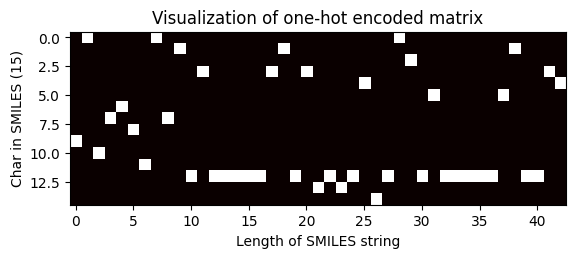

Shape of one-hot matrix :  (15, 43)
Associated canonical SMILES:  N([C@H](C)c1ccccc1)c1ncnc2oc(-c3ccccc3)cc12


In [96]:
# 选择要可视化 OHE 矩阵的化合物的索引
index = 100
one_hot_matrix_plot(
    df.iloc[index]["sklearn_ohe_matrix_no_padding"],
    df.iloc[index]["sklearn_ohe_matrix_no_padding"],
    df.iloc[index]["processed_canonical_smiles"],
)

#### 带填充（等维度）

##### 在独热编码之后进行填充

我们只需将 `sklearn_one_hot_encoded_matrix` 函数的 `islaterpadding` 布尔参数设为 **True**，如下所示，即可在进行独热编码后填充矩阵。

In [97]:
# 将函数应用于处理后的规范 SMILES 字符串
df["sklearn_ohe_matrix_later_padding"] = df["processed_canonical_smiles"].apply(
    sklearn_one_hot_encoded_matrix,
    islaterpadding=True,
    isinitialpadding=False,
    smiles_maxlen=smiles_maxlen,
    unique_char=unique_char,
)
df.head(2)

,chembl_id,canonical_smiles,Mol2D,processed_canonical_smiles,unique_char_ohe_matrix,sklearn_ohe_matrix_no_padding,sklearn_ohe_matrix_later_padding
0,CHEMBL207869,Clc1c(OCc2cc(F)ccc2)ccc(Nc2c(C#Cc3ncccn3)cncn2)c1,<rdkit.Chem.rdchem.Mol object at 0x13d0fe3b0>,Lc1c(OCc2cc(F)ccc2)ccc(Nc2c(C#Cc3ncccn3)cncn2)c1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
1,CHEMBL3940060,ClCC(=O)OCCN1C(=O)Oc2c1cc1c(Nc3cc(Cl)c(F)cc3)n...,<rdkit.Chem.rdchem.Mol object at 0x13d0fdd20>,LCC(=O)OCCN1C(=O)Oc2c1cc1c(Nc3cc(L)c(F)cc3)ncn...,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."


**独热编码矩阵的可视化（等维度）**

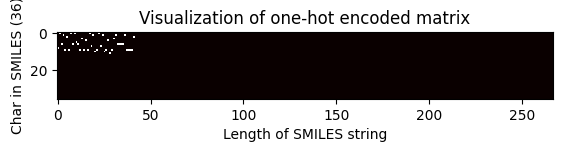

Shape of one-hot matrix :  (36, 267)
Associated canonical SMILES:  O(C)c1c(C(=Cc2c3c(N)nc(N)nc3oc2)CCCC)cccc1


In [98]:
# 选择要可视化 OHE 矩阵的化合物的索引
index = 2705
one_hot_matrix_plot(
    df.iloc[index]["sklearn_ohe_matrix_later_padding"],
    unique_char,
    df.iloc[index]["processed_canonical_smiles"],
)

##### 在独热编码之前进行填充

在这种情况下，填充在 OHE 之前但整数编码之后进行——通过将 `sklearn_one_hot_encoded_matrix` 函数的 `initial_padding` 布尔参数设为 **True**，对 SMILES 字符列表进行填充。

In [99]:
# 将函数应用于处理后的规范 SMILES 字符串
df["sklearn_ohe_matrix_initial_padding"] = df["processed_canonical_smiles"].apply(
    sklearn_one_hot_encoded_matrix,
    islaterpadding=False,
    isinitialpadding=True,
    smiles_maxlen=smiles_maxlen,
    unique_char=unique_char,
)

df.head(2)

,chembl_id,canonical_smiles,Mol2D,processed_canonical_smiles,unique_char_ohe_matrix,sklearn_ohe_matrix_no_padding,sklearn_ohe_matrix_later_padding,sklearn_ohe_matrix_initial_padding
0,CHEMBL207869,Clc1c(OCc2cc(F)ccc2)ccc(Nc2c(C#Cc3ncccn3)cncn2)c1,<rdkit.Chem.rdchem.Mol object at 0x13d0fe3b0>,Lc1c(OCc2cc(F)ccc2)ccc(Nc2c(C#Cc3ncccn3)cncn2)c1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
1,CHEMBL3940060,ClCC(=O)OCCN1C(=O)Oc2c1cc1c(Nc3cc(Cl)c(F)cc3)n...,<rdkit.Chem.rdchem.Mol object at 0x13d0fdd20>,LCC(=O)OCCN1C(=O)Oc2c1cc1c(Nc3cc(L)c(F)cc3)ncn...,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."


**独热编码矩阵的可视化（等维度）**

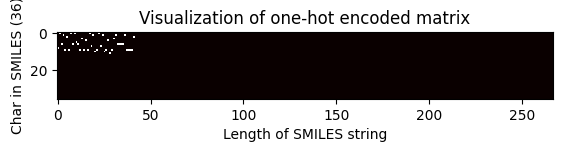

Shape of one-hot matrix :  (36, 267)
Associated canonical SMILES:  O(C)c1c(C(=Cc2c3c(N)nc(N)nc3oc2)CCCC)cccc1


In [100]:
# 选择要可视化 OHE 矩阵的化合物的索引
index = 2705
one_hot_matrix_plot(
    df.iloc[index]["sklearn_ohe_matrix_later_padding"],
    unique_char,
    df.iloc[index]["processed_canonical_smiles"],
)

### Keras 实现独热编码

Keras 也是一个非常强大且广泛使用的库，尤其用于深度学习任务。
可能有些情况下，我们已经有了整数编码的序列或字符串，那么我们可以使用 keras 库提供的 [to_categorical()](https://keras.io/api/utils/) 函数直接对整数数据进行独热编码，否则我们可以使用 [Tokenizer](https://keras.io/api/preprocessing/text/) 首先对字符串数据进行整数编码，然后使用 `to_categorical` 函数进行独热编码。

In [101]:
# 使用 keras 实现独热编码
def keras_one_hot_encoded_matrix(smiles, islaterpadding, smiles_maxlen, unique_char):
    """
    使用 keras 实现
    对 SMILES 进行独热编码。

    参数
    ----------
    canonical_char : array
        规范字符数组。
    islaterpadding : bool
        如果需要 later_padding，则参数为 `True`，
        否则为 `False`。
    smiles_maxlen : int
        SMILES 字符串的最大长度。
    unique_char : list
        字符串数据集中唯一字符的列表。

    返回
    -------
    encoded : numpy.ndarray
        形状为（SMILES 中的字符数, SMILES 的长度）的
        独热编码矩阵。
    """

    # 整数编码 using Tokenizer
    input_smiles = smiles
    tokenizer = Tokenizer(char_level=True)
    tokenizer.fit_on_texts([input_smiles])
    integer_encoded = tokenizer.texts_to_sequences([input_smiles])[0]

    # 独热编码 using to_categorical function
    encoded = to_categorical(integer_encoded)
    if islaterpadding:
        encoded = later_padding(encoded, smiles_maxlen, unique_char)
    encoded = encoded.transpose()
    return encoded

接下来，我们实现两种场景：

- 不带填充的 OHE，这将导致生成的独热编码矩阵维度不等，以及
- 通过将 `keras_one_hot_encoded_matrix` 函数中的布尔参数 `islaterpadding` 设为 `True` 来进行带后续填充的 OHE。

#### 无填充（维度不等）

In [102]:
# 将函数应用于处理后的规范 SMILES 字符串
df["keras_ohe_matrix_without_padding"] = df["processed_canonical_smiles"].apply(
    keras_one_hot_encoded_matrix,
    smiles_maxlen=smiles_maxlen,
    unique_char=unique_char,
    islaterpadding=False,
)
df.head(2)

,chembl_id,canonical_smiles,Mol2D,processed_canonical_smiles,unique_char_ohe_matrix,sklearn_ohe_matrix_no_padding,sklearn_ohe_matrix_later_padding,sklearn_ohe_matrix_initial_padding,keras_ohe_matrix_without_padding
0,CHEMBL207869,Clc1c(OCc2cc(F)ccc2)ccc(Nc2c(C#Cc3ncccn3)cncn2)c1,<rdkit.Chem.rdchem.Mol object at 0x13d0fe3b0>,Lc1c(OCc2cc(F)ccc2)ccc(Nc2c(C#Cc3ncccn3)cncn2)c1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
1,CHEMBL3940060,ClCC(=O)OCCN1C(=O)Oc2c1cc1c(Nc3cc(Cl)c(F)cc3)n...,<rdkit.Chem.rdchem.Mol object at 0x13d0fdd20>,LCC(=O)OCCN1C(=O)Oc2c1cc1c(Nc3cc(L)c(F)cc3)ncn...,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."


**独热编码矩阵的可视化（不等维度）**

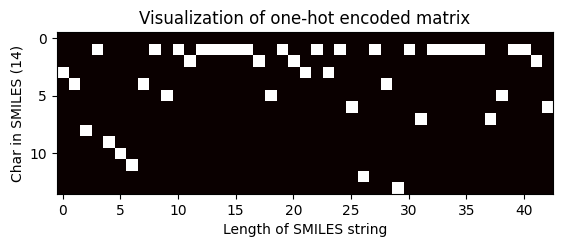

Shape of one-hot matrix :  (14, 43)
Associated canonical SMILES:  N([C@H](C)c1ccccc1)c1ncnc2oc(-c3ccccc3)cc12


In [103]:
# 选择要可视化 OHE 矩阵的化合物的索引
index = 100
one_hot_matrix_plot(
    df.iloc[index]["keras_ohe_matrix_without_padding"],
    df.iloc[index]["keras_ohe_matrix_without_padding"],
    df.iloc[index]["processed_canonical_smiles"],
)

#### 带填充（等维度）

In [104]:
# 将函数应用于处理后的规范 SMILES 字符串
df["keras_ohe_matrix_padding"] = df["processed_canonical_smiles"].apply(
    keras_one_hot_encoded_matrix,
    smiles_maxlen=smiles_maxlen,
    unique_char=unique_char,
    islaterpadding=True,
)
df.head(2)

,chembl_id,canonical_smiles,Mol2D,processed_canonical_smiles,unique_char_ohe_matrix,sklearn_ohe_matrix_no_padding,sklearn_ohe_matrix_later_padding,sklearn_ohe_matrix_initial_padding,keras_ohe_matrix_without_padding,keras_ohe_matrix_padding
0,CHEMBL207869,Clc1c(OCc2cc(F)ccc2)ccc(Nc2c(C#Cc3ncccn3)cncn2)c1,<rdkit.Chem.rdchem.Mol object at 0x13d0fe3b0>,Lc1c(OCc2cc(F)ccc2)ccc(Nc2c(C#Cc3ncccn3)cncn2)c1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
1,CHEMBL3940060,ClCC(=O)OCCN1C(=O)Oc2c1cc1c(Nc3cc(Cl)c(F)cc3)n...,<rdkit.Chem.rdchem.Mol object at 0x13d0fdd20>,LCC(=O)OCCN1C(=O)Oc2c1cc1c(Nc3cc(L)c(F)cc3)ncn...,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."


**独热编码矩阵的可视化（不等维度）**

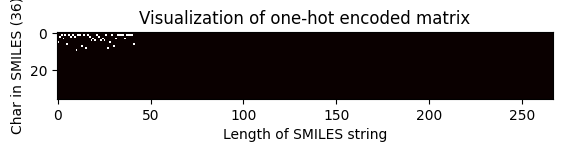

Shape of one-hot matrix :  (36, 267)
Associated canonical SMILES:  O(C)c1c(C(=Cc2c3c(N)nc(N)nc3oc2)CCCC)cccc1


In [105]:
# 选择要可视化 OHE 矩阵的化合物的索引
index = 2705
one_hot_matrix_plot(
    df.iloc[index]["keras_ohe_matrix_padding"],
    unique_char,
    df.iloc[index]["processed_canonical_smiles"],
)